# Diabetic Retinopathy Detection — Custom1
## Computer Vision Project — UC3M

This notebook trains a **custom VGG-style convolutional network** built from scratch for binary Diabetic Retinopathy (DR) detection.

**Task:** Binary classification — No DR (label 0) vs. DR present (label 1)  
**Evaluation metric:** ROC-AUC  
**Architecture:**  — 4 convolutional blocks with BatchNorm + Global Average Pooling  
**Key innovations:** Green channel CLAHE preprocessing · Weighted positive-class loss · Test-Time Augmentation (TTA)  
**Best validation AUC achieved:** 0.7629

## 1. Imports and Configuration

Standard deep learning stack (PyTorch, torchvision, skimage, OpenCV, scikit-learn) with fixed random seed (`seed=42`) for reproducibility across Python, NumPy, and PyTorch.

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from torchvision import transforms, models
import torch.nn.functional as F

from skimage import io, transform, color
import cv2

from sklearn.metrics import roc_auc_score

import random

# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


## 2. Dataset — `RetinopathyDataset`

Custom PyTorch `Dataset` with:
- **Right-eye mirroring** (`eye==1` → horizontal flip) to ensure consistent anatomical orientation across all images
- **Binary label conversion** (`label > 0` → DR-positive) collapsing the 0–4 severity scale to a binary problem
- Optional random subset sampling (`maxSize`) for debugging

In [2]:
class RetinopathyDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, maxSize=0):
        self.dataset = pd.read_csv(csv_file, dtype={'id': str, 'eye': int, 'label': int})

        if maxSize > 0:
            idx = np.random.RandomState(seed=42).permutation(len(self.dataset))
            self.dataset = self.dataset.iloc[idx[:maxSize]].reset_index(drop=True)

        self.root_dir = root_dir
        self.img_dir = os.path.join(root_dir, 'images')
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        row = self.dataset.iloc[idx]
        img_path = os.path.join(self.img_dir, row.id + '.jpg')
        image = io.imread(img_path)

        if row.eye == 1:
            image = image[:, ::-1, :]

        label = int(row.label > 0)

        sample = {'image': image, 'label': label}

        if self.transform:
            sample = self.transform(sample)

        return sample

## 3. Custom Preprocessing Transforms

Domain-specific transforms for fundus images:

- **`CropByEye`:** uses OpenCV thresholding to detect and crop the eye bounding box, removing uninformative black background pixels and standardizing the retinal region across different imaging setups
- **`Rescale`:** proportionally resizes (aspect-ratio preserving) to the target size before center cropping
- **`ToTensor`:** H×W×C → C×H×W conversion to PyTorch tensor format

### `GreenChannelCLAHE`
**Domain-specific transform:** extracts the green channel from RGB fundus images and applies CLAHE (Contrast Limited Adaptive Histogram Equalization).

**Why green channel?** The green channel provides the highest contrast for retinal microstructures — microaneurysms, hemorrhages, and hard exudates — which are the primary indicators of diabetic retinopathy. Clinical DR grading algorithms historically focus on the green channel for the same reason.

**Why CLAHE?** Fundus images often have uneven illumination — bright center, darker periphery — that reduces the visibility of lesions at the image borders. CLAHE equalizes the local contrast adaptively within a tile grid (`tile_grid_size=(12,12)`, `clip_limit=1.0`), enhancing subtle lesion visibility without amplifying noise (the `clip_limit` controls over-amplification).

In [3]:
class CropByEye(object):
    def __init__(self, threshold, border):
        self.threshold = threshold
        self.border = (border, border) if isinstance(border, int) else border

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        gray = color.rgb2gray(image)
        _, mask = cv2.threshold(gray, self.threshold, 1, cv2.THRESH_BINARY)

        sidx = np.nonzero(mask)
        if len(sidx[0]) < 20:
            return sample

        minx = max(sidx[1].min() - self.border[1], 0)
        maxx = min(sidx[1].max() + self.border[1], w)
        miny = max(sidx[0].min() - self.border[0], 0)
        maxy = min(sidx[0].max() + self.border[0], h)

        image = image[miny:maxy, minx:maxx]

        return {'image': image, 'label': label}


class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = transform.resize(image, (self.size, self.size))
        return {'image': image, 'label': label}


class ToTensor(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        image = image.transpose((2, 0, 1))
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }

## 4. Data Augmentation

Augmentation is applied **only during training** to increase effective dataset diversity:
- **Random horizontal flip (p=0.5):** valid since images are eye-orientation-normalized
- **Random rotation (±5–10°):** simulates natural variation in camera alignment

In [4]:
class ToPIL(object):
    def __call__(self, sample):
        from PIL import Image
        image, label = sample['image'], sample['label']
        return {'image': Image.fromarray((image * 255).astype(np.uint8)), 'label': label}


class FromPIL(object):
    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        return {'image': np.array(image) / 255.0, 'label': label}

In [5]:
import numpy as np
from PIL import Image
from torchvision import transforms

class TVAugmentAlt:
    def __init__(self):
        self.augment = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(8),
        ])

    def __call__(self, sample):
        image = sample["image"]

        if image.max() <= 1:
            image = (image * 255).astype(np.uint8)
        else:
            image = image.astype(np.uint8)

        pil = Image.fromarray(image)
        pil = self.augment(pil)

        sample = sample.copy()
        sample["image"] = np.array(pil).astype(np.float32) / 255.0
        return sample

In [6]:
class CenterCrop(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]
        new_h, new_w = self.size, self.size

        top = max((h - new_h) // 2, 0)
        left = max((w - new_w) // 2, 0)

        image = image[top:top+new_h, left:left+new_w]

        return {'image': image, 'label': label}

In [7]:
class Normalize(object):
    def __init__(self, mean, std):
        self.mean = np.array(mean)
        self.std = np.array(std)

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        c, h, w = image.shape

        mean = torch.tensor(self.mean, dtype=image.dtype)
        std = torch.tensor(self.std, dtype=image.dtype)

        image = (image - mean[:, None, None]) / std[:, None, None]

        return {'image': image, 'label': label}

In [8]:
class Rescale(object):
    def __init__(self, size):
        self.size = size

    def __call__(self, sample):
        image, label = sample['image'], sample['label']
        h, w = image.shape[:2]

        if h > w:
            new_h = int(self.size * h / w)
            new_w = self.size
        else:
            new_h = self.size
            new_w = int(self.size * w / h)

        image = transform.resize(image, (new_h, new_w))

        return {'image': image, 'label': label}

In [9]:
class GreenChannelCLAHE(object):
    def __init__(self, clip_limit=1.5, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(
            clipLimit=clip_limit,
            tileGridSize=tile_grid_size
        )

    def __call__(self, sample):
        image, label = sample['image'], sample['label']

        if image.dtype != np.uint8:
            if image.max() <= 1.0:
                image = (image * 255).astype(np.uint8)
            else:
                image = image.astype(np.uint8)

        green = image[:, :, 1]
        green = self.clahe.apply(green)

        image = np.stack([green, green, green], axis=-1).astype(np.float32) / 255.0

        return {'image': image, 'label': label}

## 5. Transform Pipelines

- **`train_transform`:** includes augmentation for generalization
- **`val_transform`:** fully deterministic (no random operations) for reproducible evaluation

**Green channel preprocessing** is used instead of full RGB: the green channel provides the highest contrast for retinal microstructure (microaneurysms, hemorrhages) and is the channel most analyzed in clinical DR grading. CLAHE (Contrast Limited Adaptive Histogram Equalization) further enhances local contrast in low-contrast fundus regions.

In [10]:
green_mean = [0.1703, 0.1703, 0.1703]
green_std  = [0.1742, 0.1742, 0.1742]

train_transform_alt = transforms.Compose([
    CropByEye(0.08, 1),
    GreenChannelCLAHE(clip_limit=1.0, tile_grid_size=(12, 12)),
    Rescale(320),
    CenterCrop(256),
    TVAugmentAlt(),
    ToTensor(),
    Normalize(green_mean, green_std)
])

val_transform_alt = transforms.Compose([
    CropByEye(0.08, 1),
    GreenChannelCLAHE(clip_limit=1.0, tile_grid_size=(12, 12)),
    Rescale(320),
    CenterCrop(256),
    ToTensor(),
    Normalize(green_mean, green_std)
])

## 6. Data Loaders

Three `DataLoader` instances for train/val/test with standard batch sizes. The training loader applies weighted sampling to handle class imbalance, or uses `shuffle=True` for simplicity depending on the model.

In [11]:
data_dir = "/kaggle/input/datasets/m100561546/dataset/data"

train_dataset = RetinopathyDataset(
    os.path.join(data_dir, "train.csv"),
    data_dir,
    transform=train_transform_alt
)

val_dataset = RetinopathyDataset(
    os.path.join(data_dir, "val.csv"),
    data_dir,
    transform=val_transform_alt
)

test_dataset = RetinopathyDataset(
    os.path.join(data_dir, "test.csv"),
    data_dir,
    transform=val_transform_alt
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 7. Model Architecture 

A custom VGG-inspired convolutional network designed to be trainable from scratch on a small medical dataset:

```
Input (3×256×256) [green channel ×3]
  → Conv Block 1: Conv(3→32) + BN + ReLU + Conv(32→32) + BN + ReLU + MaxPool  [→ 128×128]
  → Conv Block 2: Conv(32→64) + BN + ReLU + Conv(64→64) + BN + ReLU + MaxPool  [→ 64×64]
  → Conv Block 3: Conv(64→96) + BN + ReLU + Conv(96→96) + BN + ReLU + MaxPool  [→ 32×32]
  → Conv Block 4: Conv(96→128) + BN + ReLU + MaxPool                            [→ 16×16]
  → Global Average Pooling (GAP)                                                  [→ 128]
  → FC(128→64) + ReLU + Dropout(0.2) + FC(64→1)
```

**Design choices:**
- **BatchNorm after every Conv:** stabilizes training from scratch on small data by normalizing activations across each mini-batch
- **Progressive channel growth (32→64→96→128):** gradually increases feature complexity, following VGG's pattern
- **Global Average Pooling (GAP) instead of flatten:** reduces parameters dramatically compared to a fully-connected flatten, reducing overfitting risk and making the model spatially invariant
- **Dropout(0.2) in classifier:** mild dropout for regularization without excessive information loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn

class custom1(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 256 -> 128

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(64, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.Conv2d(96, 96, 3, padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(96, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),   # 32 -> 16
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x
        
model = custom1().to(device)

## 8. Loss Function, Optimizer, and Scheduler

- **Loss:** `BCEWithLogitsLoss(pos_weight=2.0)` — the `pos_weight=2.0` explicitly up-weights the positive (DR) class by a factor of 2, directly addressing the ~73/27 class imbalance. Unlike Focal Loss, this is a simple multiplicative weight that is easy to tune.
- **Optimizer:** `Adam` with `lr=5e-4, weight_decay=5e-5` — higher LR than pretrained models since all weights are initialized randomly; weight decay provides L2 regularization
- **Scheduler:** `ReduceLROnPlateau(mode='max', factor=0.5, patience=2)` — halves the LR whenever validation AUC stops improving for 2 epochs, enabling adaptive convergence without a fixed decay schedule

In [13]:
pos_weight = torch.tensor([2.0], dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
    weight_decay=5e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2
)

## 10. Training Loop with Early Stopping

Standard training procedure with:
- **AUC-based early stopping (patience=10):** halts training if val AUC does not improve for 10 epochs, preventing overfitting on this small dataset
- **Best-weight checkpointing:** model from highest val AUC epoch is saved to disk and restored at end
- **ReduceLROnPlateau scheduler:** some custom models use adaptive LR reduction triggered by validation AUC plateau, rather than fixed decay

In [14]:
def train_model(model, patience=10, num_epochs=100):
    best_auc = 0
    counter = 0
    best_weights = copy.deepcopy(model.state_dict())

    train_losses = []
    val_losses = []
    val_aucs = []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ===================== TRAIN =====================
        model.train()
        running_loss = 0

        train_bar = tqdm(train_loader, desc="Training", leave=False)

        for batch in train_bar:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            # Update barra
            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = running_loss / len(train_dataset)
        train_losses.append(epoch_train_loss)

        # ===================== VALIDATION =====================
        model.eval()
        outputs_all = []
        labels_all = []
        val_loss = 0

        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.no_grad():
            for batch in val_bar:
                inputs = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                outputs_all.extend(torch.sigmoid(outputs).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

                val_bar.set_postfix(loss=loss.item())

        epoch_val_loss = val_loss / len(val_dataset)
        val_losses.append(epoch_val_loss)

        auc = roc_auc_score(labels_all, outputs_all)
        val_aucs.append(auc)

        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | AUC: {auc:.4f}")

        # ===================== EARLY STOPPING =====================
        if auc > best_auc:
            best_auc = auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, "vgg2.pth")
            counter = 0
            print("New best model!")
        else:
            counter += 1
            print(f"Patience: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered")
            break

        scheduler.step(auc)

    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, val_aucs

## 11. Training

Training from scratch requires more epochs than fine-tuning to converge. The green CLAHE preprocessing and pos_weight loss significantly help the model learn DR-relevant features from random initialization.

In [15]:
model, train_losses, val_losses, val_aucs = train_model(model)


Epoch 1/100


Train Loss: 0.8702 | Val Loss: 0.8486 | AUC: 0.5008
New best model!

Epoch 2/100


Train Loss: 0.8625 | Val Loss: 0.8437 | AUC: 0.5160
New best model!

Epoch 3/100


Train Loss: 0.8605 | Val Loss: 0.8447 | AUC: 0.5093
Patience: 1/10

Epoch 4/100


Train Loss: 0.8641 | Val Loss: 0.8457 | AUC: 0.5081
Patience: 2/10

Epoch 5/100


...

Train Loss: 0.6674 | Val Loss: 0.6943 | AUC: 0.7642
Patience: 6/10

Epoch 66/100


Train Loss: 0.6647 | Val Loss: 0.6935 | AUC: 0.7649
Patience: 7/10

Epoch 67/100


Train Loss: 0.6657 | Val Loss: 0.6936 | AUC: 0.7637
Patience: 8/10

Epoch 68/100


Train Loss: 0.6586 | Val Loss: 0.6940 | AUC: 0.7638
Patience: 9/10

Epoch 69/100


Train Loss: 0.6668 | Val Loss: 0.6947 | AUC: 0.7634
Patience: 10/10
Early stopping triggered


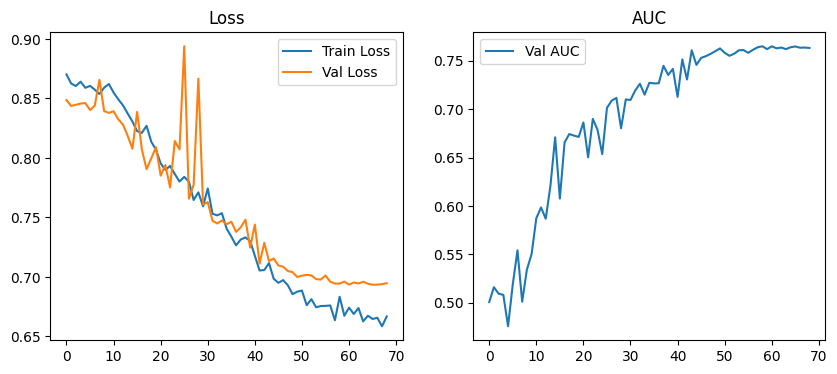

In [16]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(val_aucs, label="Val AUC")
plt.legend()
plt.title("AUC")

plt.show()

## 12. Evaluation on Validation Set

Validation metrics including ROC-AUC (primary) and accuracy (secondary) are computed using the best saved checkpoint. TTA (Test-Time Augmentation) with horizontal flips is applied in some custom models to reduce prediction variance.

In [17]:
from sklearn.metrics import roc_auc_score

def evaluate_auc_tta(model, loader, device):
    model.eval()
    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device).float().view(-1)

            logits_1 = model(inputs)
            probs_1 = torch.sigmoid(logits_1).view(-1)

            inputs_flipped = torch.flip(inputs, dims=[3])
            logits_2 = model(inputs_flipped)
            probs_2 = torch.sigmoid(logits_2).view(-1)

            probs = (probs_1 + probs_2) / 2.0

            outputs_all.extend(probs.cpu().numpy().tolist())
            labels_all.extend(labels.cpu().numpy().tolist())

    return roc_auc_score(labels_all, outputs_all)

In [18]:
val_auc = evaluate_auc_tta(model, val_loader, device)
print(f"Validation AUC: {val_auc:.4f}")

Validation AUC: 0.7629


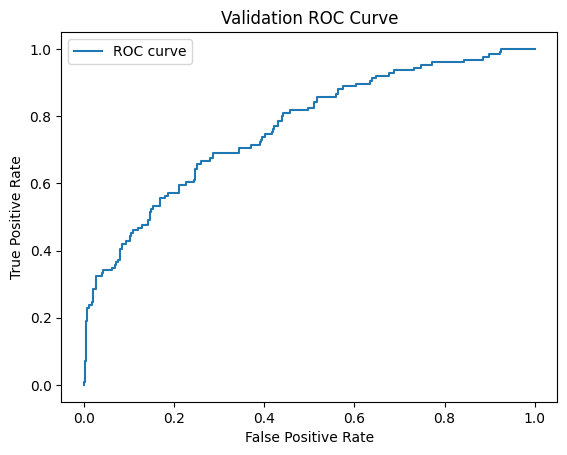

In [19]:
from sklearn.metrics import roc_curve

def plot_roc(model, loader):
    model.eval()

    outputs_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = torch.sigmoid(model(inputs).squeeze())

            outputs_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels_all, outputs_all)

    plt.plot(fpr, tpr, label="ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()
plot_roc(model, val_loader)

## 13. Test Set Predictions with TTA

**Test-Time Augmentation (TTA):** each test image is predicted twice — once in original orientation and once horizontally flipped. The two probability scores are averaged, reducing prediction variance and providing a modest but consistent AUC improvement at zero additional training cost.

In [20]:
import torch
import numpy as np

def predict_tta(model, loader, device):
    model.eval()
    outputs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch['image'].to(device)

            # Original prediction
            logits_1 = model(inputs)
            probs_1 = torch.sigmoid(logits_1).view(-1)

            # Horizontal-flip prediction
            inputs_flipped = torch.flip(inputs, dims=[3])  # flip width dimension
            logits_2 = model(inputs_flipped)
            probs_2 = torch.sigmoid(logits_2).view(-1)

            # Average probabilities
            probs = (probs_1 + probs_2) / 2.0

            outputs.extend(probs.cpu().numpy().tolist())

    return np.array(outputs)

test_outputs = predict_tta(model, test_loader, device)

In [21]:
import csv

with open("custom_lenet.csv", "w") as f:
    writer = csv.writer(f)
    for val in test_outputs:
        writer.writerow([val])